In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Ordinary Differential Equations (ODEs)

## What is an ODE?
An ODE is an equation relating a function to its derivatives:

    x'(t) = f(t, x(t)),    x(0) = x_init

We know the initial condition x(0) and want to reconstruct x(t) for t > 0.

## Numerical methods
Since most ODEs have no closed-form solution, we approximate them numerically.
We discretize time into N steps of size dt = T/N, and build the solution step by step.

Two methods are implemented here:

- **Euler explicit** — simple, first-order accuracy: O(1/N)
- **Runge-Kutta 4 (RK4)** — more accurate, fourth-order: O(1/N⁴)

## Models studied
1. Exponential growth — x'(t) = rx(t)
2. Lotka-Volterra — predator-prey system
3. SIR epidemic model

In [4]:
def euler(f, x0, T, N):
    dt = T / N
    t = np.linspace(0, T, N+1)
    x = np.zeros(N+1)
    x[0] = x0
    for i in range(N):
        x[i+1] = x[i] + dt * f(t[i], x[i])
    return t, x

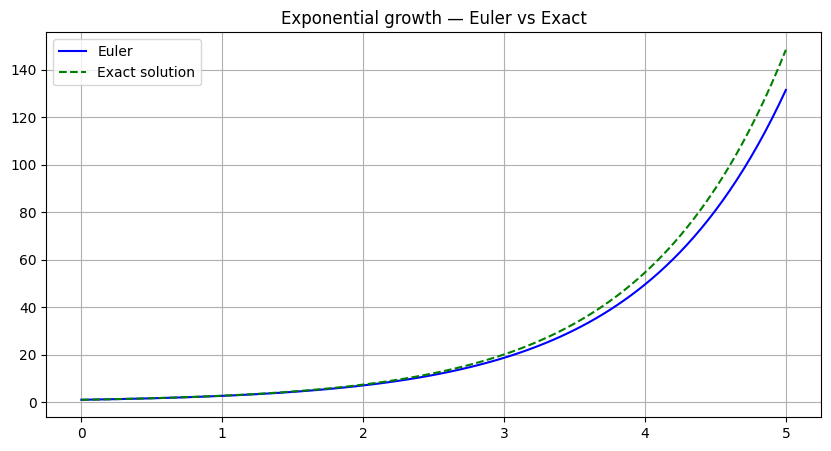

In [10]:
r = 1
f = lambda t, x: r * x

t, x_euler = euler(f, x0=1, T=5, N=100)
x_exact = np.exp(r * t)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(t, x_euler, 'b-', label='Euler')
ax.plot(t, x_exact, 'g--', label='Exact solution')
ax.set_title('Exponential growth — Euler vs Exact')
ax.legend()
ax.grid(True)
plt.show()

In [11]:
def rk4(f, x0, T, N):
    dt = T / N
    t = np.linspace(0, T, N+1)
    x = np.zeros(N+1)
    x[0] = x0
    for i in range(N):
        k1 = f(t[i], x[i])
        k2 = f(t[i] + dt/2, x[i] + dt/2 * k1)
        k3 = f(t[i] + dt/2, x[i] + dt/2 * k2)
        k4 = f(t[i] + dt, x[i] + dt * k3)
        x[i+1] = x[i] + dt/6 * (k1 + 2*k2 + 2*k3 + k4)
    return t, x

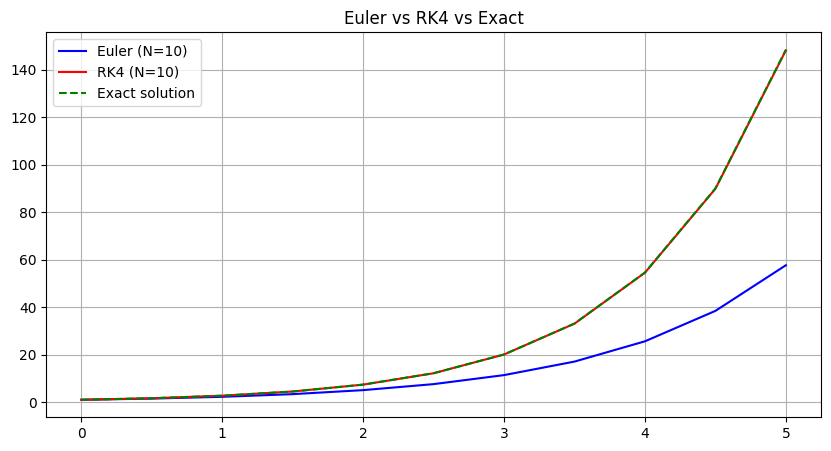

In [12]:
r = 1
f = lambda t, x: r * x

t, x_euler = euler(f, x0=1, T=5, N=10)
t, x_rk4 = rk4(f, x0=1, T=5, N=10)
x_exact = np.exp(r * t)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(t, x_euler, 'b-', label='Euler (N=10)')
ax.plot(t, x_rk4, 'r-', label='RK4 (N=10)')
ax.plot(t, x_exact, 'g--', label='Exact solution')
ax.set_title('Euler vs RK4 vs Exact')
ax.legend()
ax.grid(True)
plt.show()

## Lotka-Volterra Predator-Prey Model

The Lotka-Volterra model describes the interaction between two populations:
- x(t) : prey population
- y(t) : predator population

### Equations

    x'(t) = ax(t) - bx(t)y(t)
    y'(t) = -cy(t) + dx(t)y(t)

### Parameters
- a : prey growth rate (without predators)
- b : predation rate
- c : predator death rate (without prey)
- d : predator growth rate (from predation)

### Equilibrium points
- (0, 0) : extinction of both populations
- (c/d, a/b) : coexistence equilibrium

### Key property
Solutions are periodic : both populations oscillate indefinitely.
We visualize this in two ways:
- Time series : x(t) and y(t) as functions of t
- Phase plane : trajectory (x(t), y(t)) in the (x, y) plane

In [13]:
def rk4_system(f, u0, T, N):
    dt = T / N
    t = np.linspace(0, T, N+1)
    u = np.zeros((N+1, len(u0)))
    u[0] = u0
    for i in range(N):
        k1 = f(t[i], u[i])
        k2 = f(t[i] + dt/2, u[i] + dt/2 * k1)
        k3 = f(t[i] + dt/2, u[i] + dt/2 * k2)
        k4 = f(t[i] + dt, u[i] + dt * k3)
        u[i+1] = u[i] + dt/6 * (k1 + 2*k2 + 2*k3 + k4)
    return t, u

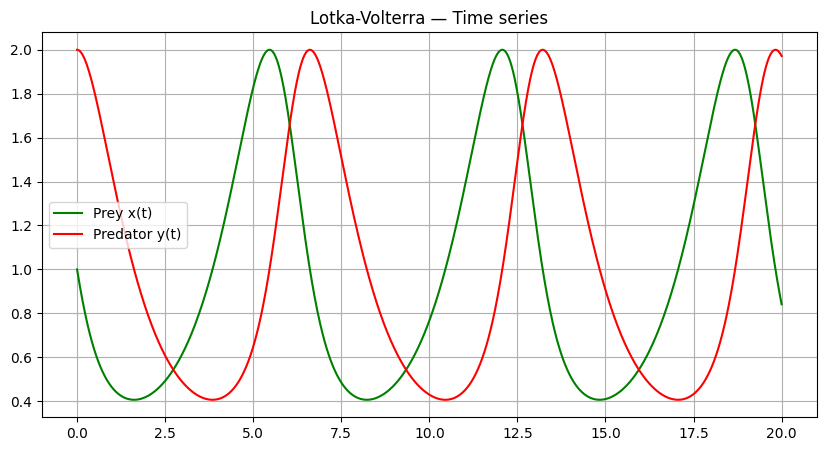

In [14]:
a, b, c, d = 1, 1, 1, 1

def lotka_volterra(t, u):
    x, y = u
    return np.array([a*x - b*x*y, -c*y + d*x*y])

t, u = rk4_system(lotka_volterra, u0=[1, 2], T=20, N=1000)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(t, u[:, 0], 'g-', label='Prey x(t)')
ax.plot(t, u[:, 1], 'r-', label='Predator y(t)')
ax.set_title('Lotka-Volterra — Time series')
ax.legend()
ax.grid(True)
plt.show()

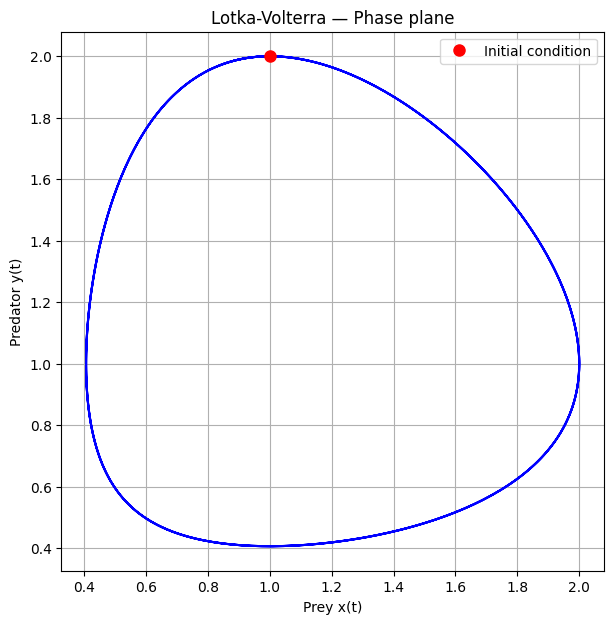

In [15]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(u[:, 0], u[:, 1], 'b-')
ax.plot(u[0, 0], u[0, 1], 'ro', markersize=8, label='Initial condition')
ax.set_xlabel('Prey x(t)')
ax.set_ylabel('Predator y(t)')
ax.set_title('Lotka-Volterra — Phase plane')
ax.legend()
ax.grid(True)
plt.show()

## SIR Epidemic Model

The SIR model describes the spread of a disease in a population divided into 3 compartments:
- x(t) : Susceptible (healthy individuals)
- y(t) : Infected
- z(t) : Recovered (immune or deceased)

### Equations

    x'(t) = -k * (y(t) / (x(t) + y(t) + z(t))) * x(t)
    y'(t) =  k * (y(t) / (x(t) + y(t) + z(t))) * x(t) - l*y(t)
    z'(t) =  l * y(t)

### Parameters
- k : infection rate
- l : recovery rate

### Key properties
- Total population is conserved : x(t) + y(t) + z(t) = constant
- If k > l : epidemic peak, many individuals get infected
- If k < l : no epidemic, infected population decreases immediately

### Initial conditions
- x(0) = S : initial healthy population
- y(0) = m : initial infected population (small)
- z(0) = 0 : no recovered individuals at t=0

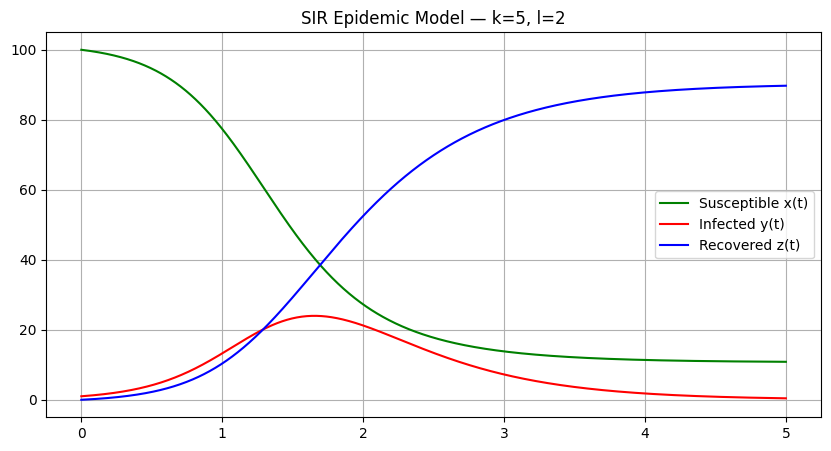

In [18]:
def sir(t, u):
    x, y, z = u
    N = x + y + z
    k, l = 5, 2
    dxdt = -k * (y/N) * x
    dydt =  k * (y/N) * x - l*y
    dzdt =  l * y
    return np.array([dxdt, dydt, dzdt])

t, u = rk4_system(sir, u0=[100, 1, 0], T=5, N=1000)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(t, u[:, 0], 'g-', label='Susceptible x(t)')
ax.plot(t, u[:, 1], 'r-', label='Infected y(t)')
ax.plot(t, u[:, 2], 'b-', label='Recovered z(t)')
ax.set_title('SIR Epidemic Model — k=5, l=2')
ax.legend()
ax.grid(True)
plt.show()